<a href="https://colab.research.google.com/github/teriyako/bertscan/blob/main/mobilebert_lamda_findings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MobileBERT LAMDA Findings

This notebook presents the final research-facing results for the `2026-04-15-mobilebert-finetuning` project.
It summarizes the saved final run rather than retraining the model.

## Scope

- Model: `google/mobilebert-uncased`
- Feature space: Drebin `215` features plus `class`
- Training slice: balanced `2023+2024`
- Temporal holdout: `2025`
- Final report: `reports/mobilebert_lamda_drebin216_report.json`
- Build summary: `reports/lamda_drebin216_build_summary.json`

In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_DIR = Path('/home/admin/workspace/projects/2026-04-15-mobilebert-finetuning')
REPORT_PATH = PROJECT_DIR / 'reports' / 'mobilebert_lamda_drebin216_report.json'
BUILD_SUMMARY_PATH = PROJECT_DIR / 'reports' / 'lamda_drebin216_build_summary.json'
FINDINGS_SUMMARY_PATH = PROJECT_DIR / 'notebooks' / 'results' / 'findings_summary.json'
FIGURES_DIR = PROJECT_DIR / 'notebooks' / 'results' / 'figures'

report = json.loads(REPORT_PATH.read_text())
build_summary = json.loads(BUILD_SUMMARY_PATH.read_text())
findings_summary = json.loads(FINDINGS_SUMMARY_PATH.read_text())


## Metric Table

In [ ]:
metric_table = pd.DataFrame([
    {
        'split': 'validation',
        'accuracy': report['validation_metrics']['eval_accuracy'],
        'f1': report['validation_metrics']['eval_f1'],
        'pr_auc': report['validation_metrics']['eval_average_precision'],
        'roc_auc': report['validation_metrics']['eval_roc_auc'],
    },
    {
        'split': 'test',
        'accuracy': report['test_metrics']['accuracy'],
        'f1': report['test_metrics']['f1'],
        'pr_auc': report['test_metrics']['average_precision'],
        'roc_auc': report['test_metrics']['roc_auc'],
    },
    {
        'split': 'temporal_2025',
        'accuracy': report['temporal_2025_metrics']['accuracy'],
        'f1': report['temporal_2025_metrics']['f1'],
        'pr_auc': report['temporal_2025_metrics']['average_precision'],
        'roc_auc': report['temporal_2025_metrics']['roc_auc'],
    },
]).round(4)
metric_table

,split,accuracy,f1,pr_auc,roc_auc
0,validation,0.9057,0.9008,0.9658,0.9559
1,test,0.8917,0.8860,0.9605,0.9489
2,temporal_2025,0.9319,0.0046,0.0033,0.7566


## Key Findings

In [ ]:
display(Markdown(
    f"""
- **Mapped Drebin features:** {build_summary['mapped_drebin_features']} / {build_summary['drebin_feature_count']}
- **Recent balanced rows after empty-text filtering:** {findings_summary['effective_recent_rows']:,}
- **Temporal 2025 rows after empty-text filtering:** {findings_summary['effective_temporal_rows']:,}
- **Android export:** `{report['artifacts']['torchscript_model']}`
- **Tokenizer bundle:** `{report['artifacts']['tokenizer_dir']}`
"""
))


- **Mapped Drebin features:** 135 / 215  
- **Recent balanced rows after empty-text filtering:** 17,360  
- **Temporal 2025 rows after empty-text filtering:** 44,600  
- **Android export:** `/home/admin/workspace/projects/2026-04-15-mobilebert-finetuning/artifacts/mobilebert-lamda-20260415-095452/mobilebert_lamda_drebin216_android.pt`  
- **Tokenizer bundle:** `/home/admin/workspace/projects/2026-04-15-mobilebert-finetuning/artifacts/mobilebert-lamda-20260415-095452/mobilebert_tokenizer`


## Dataset Balance

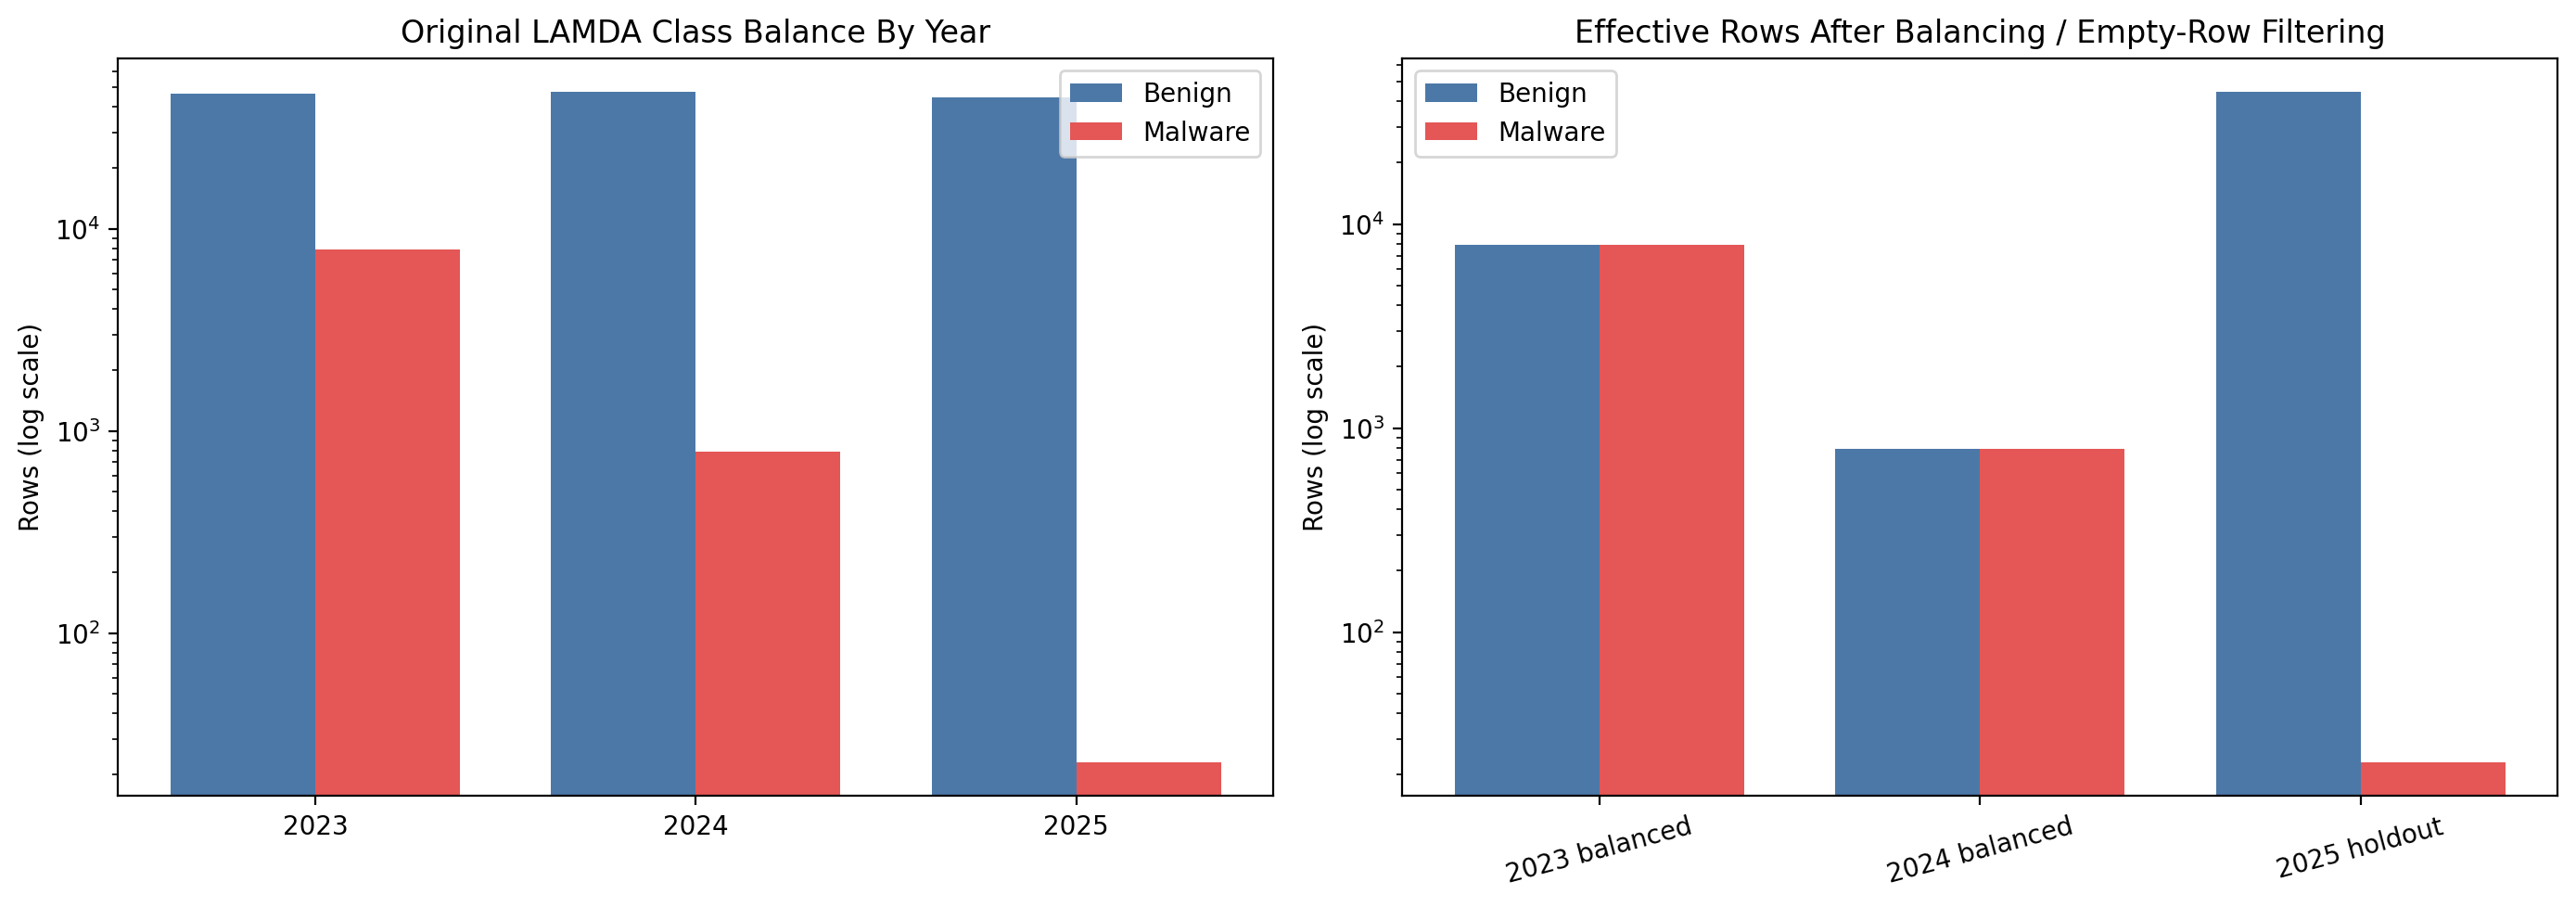

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'dataset_balance_by_year.png')))

## Feature Mapping Coverage

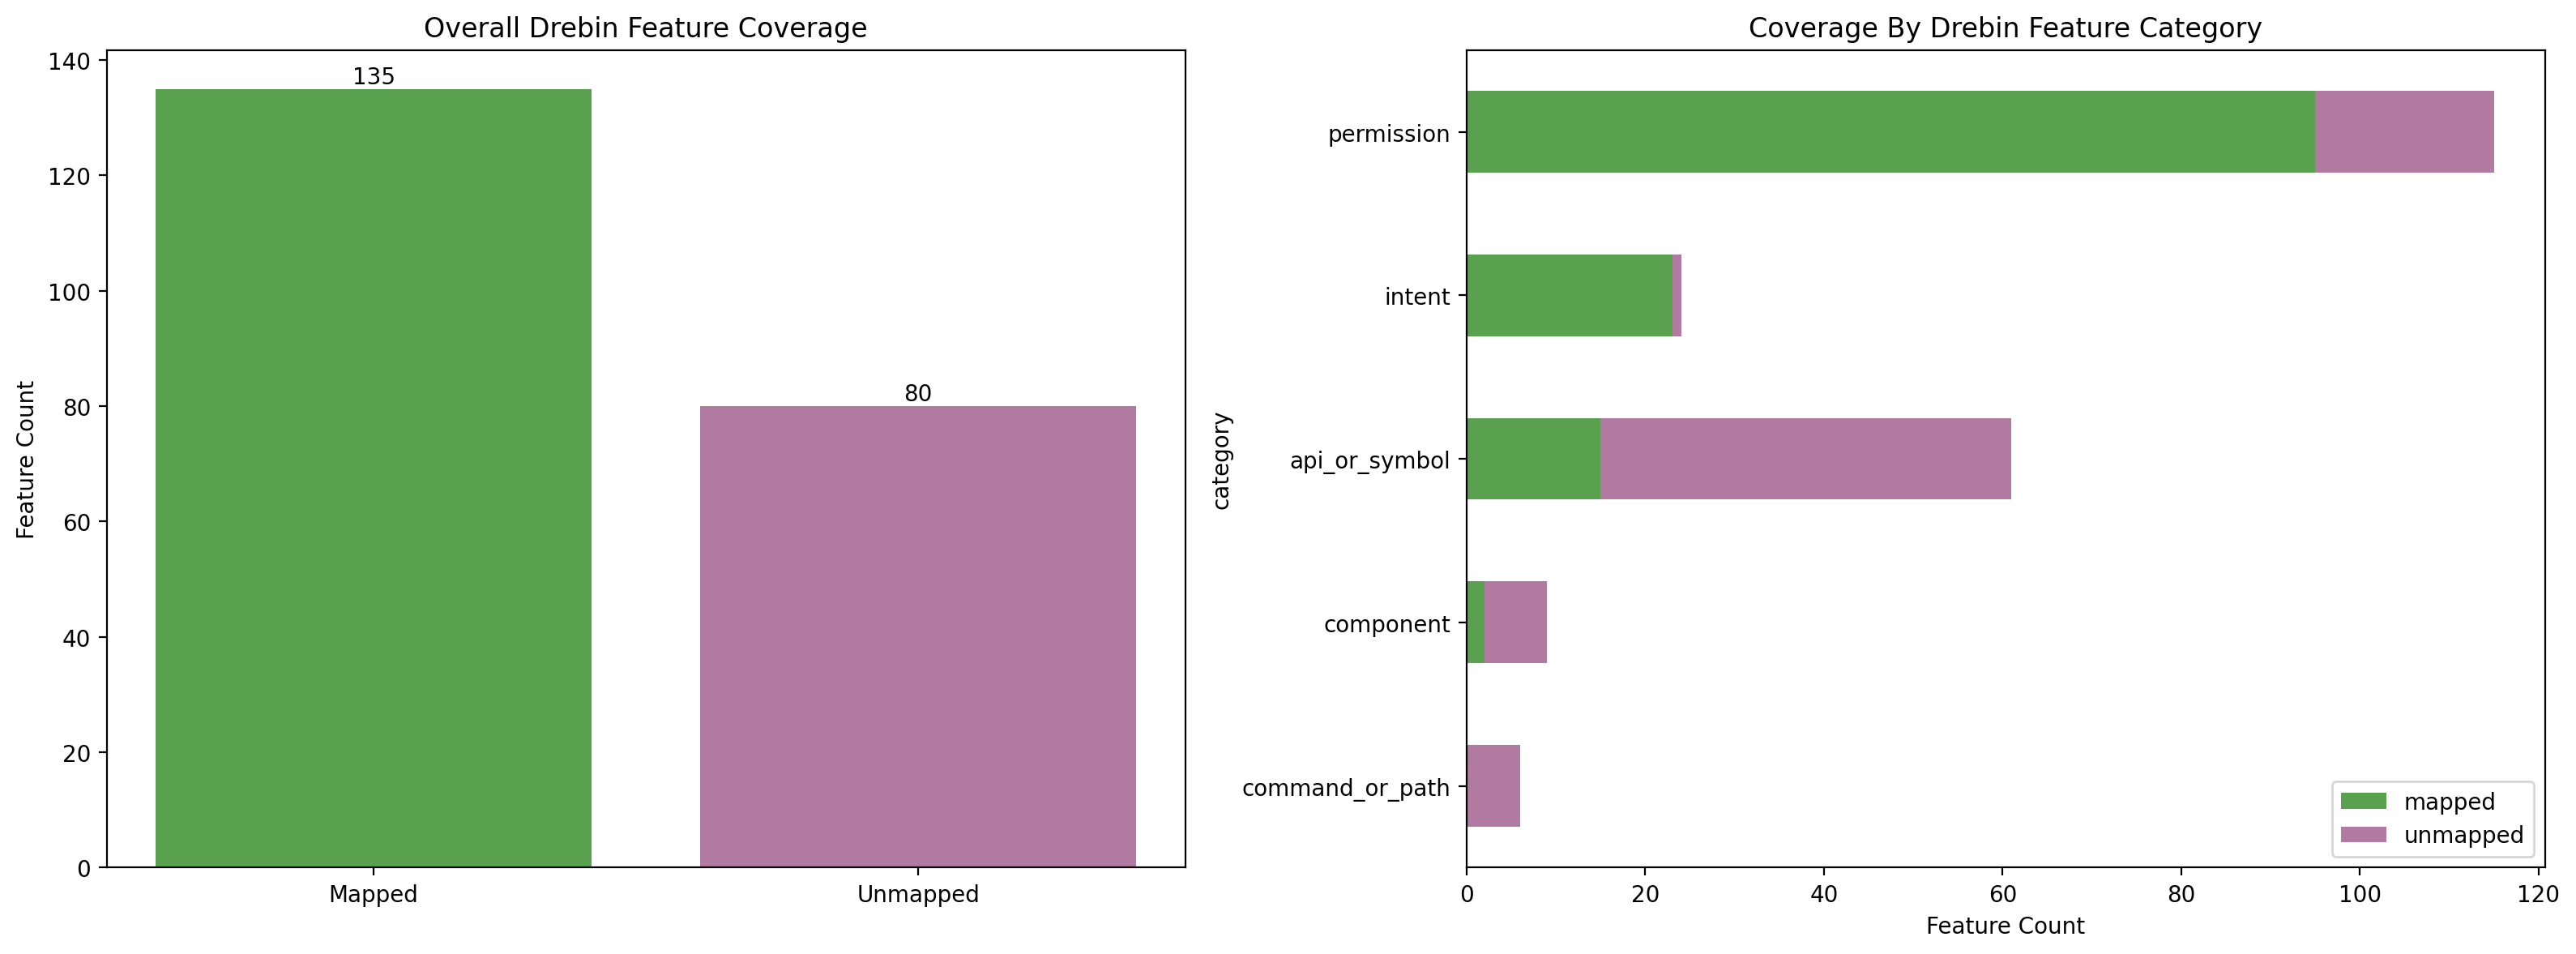

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'feature_mapping_coverage.png')))

## Training Curves

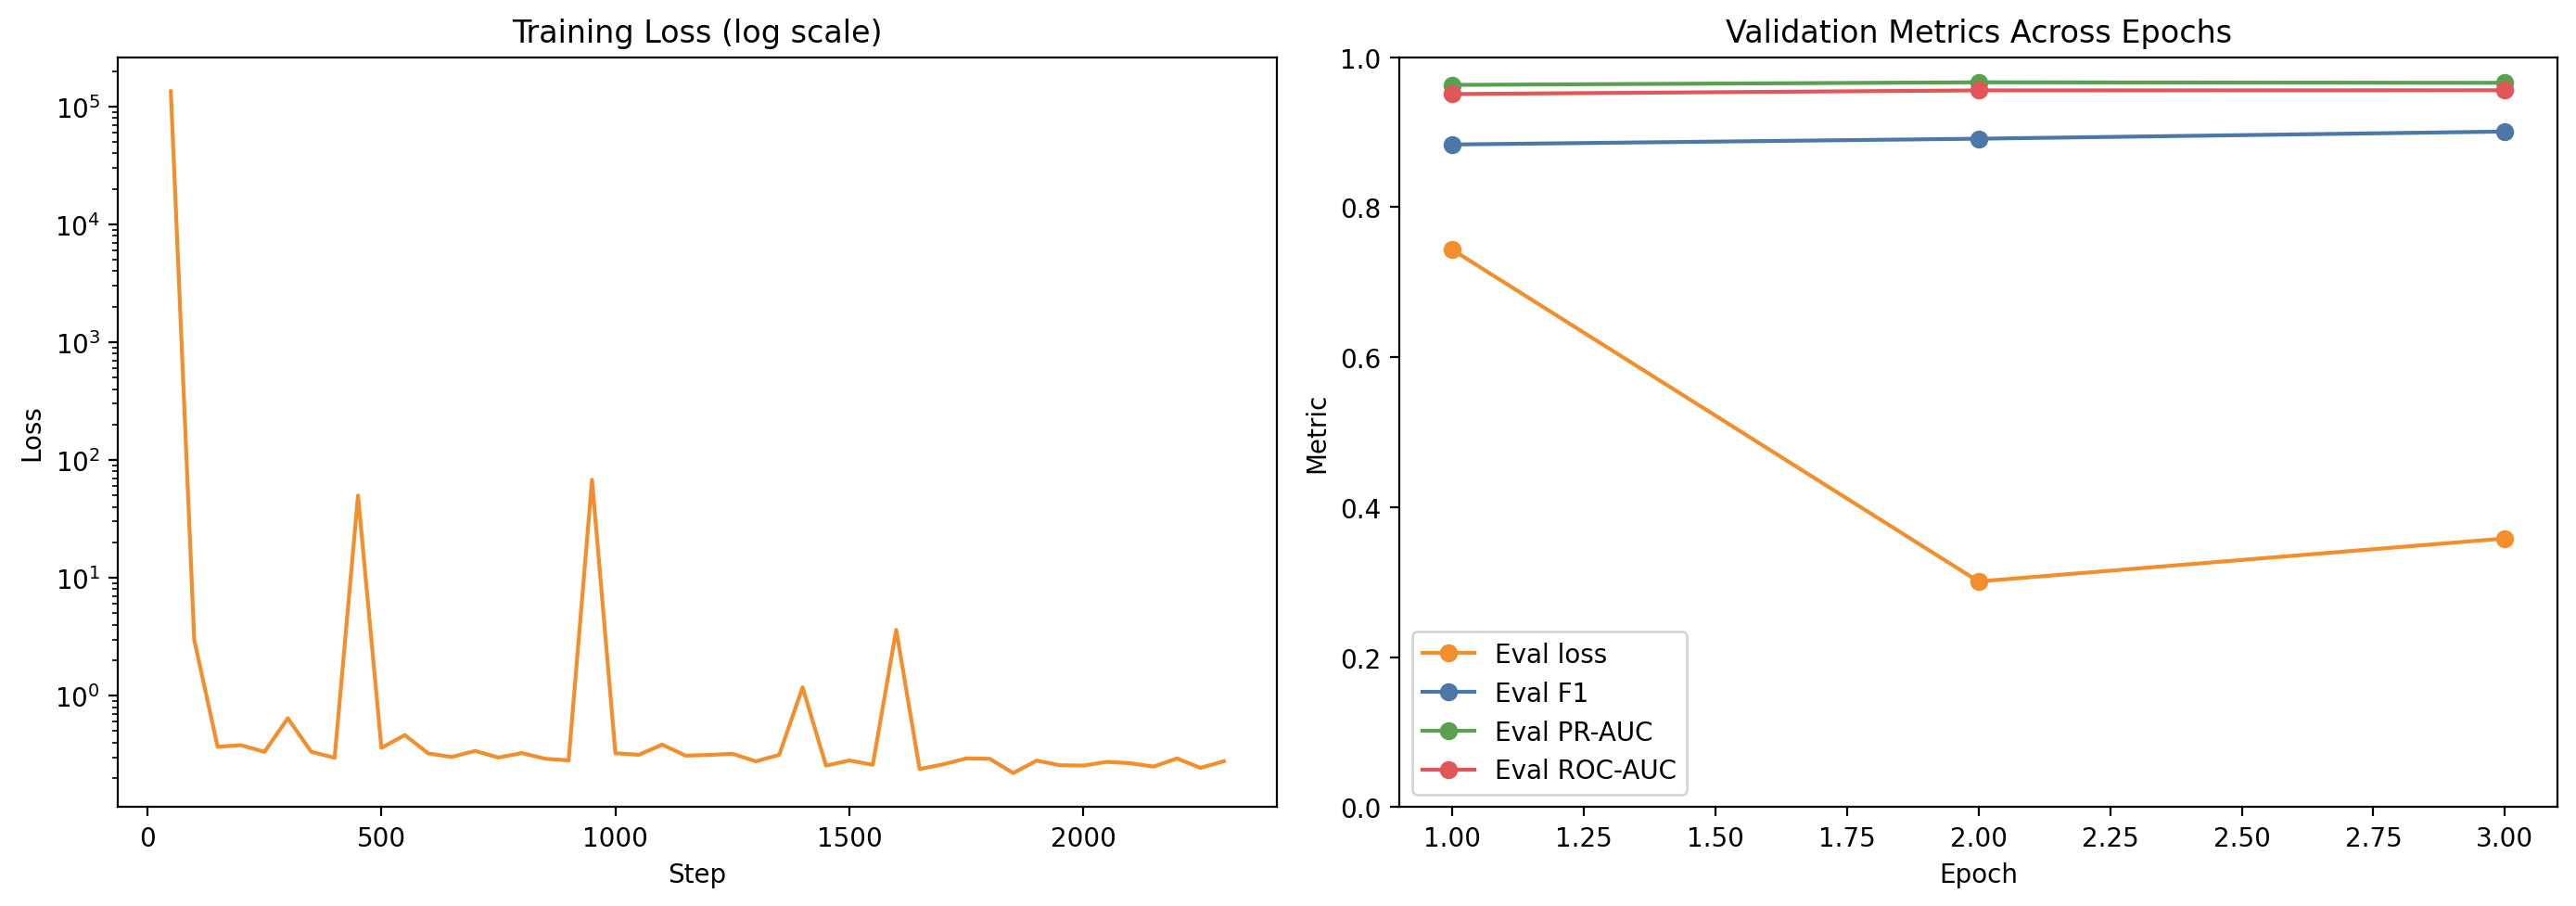

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'training_curves.png')))

## Metric Summary

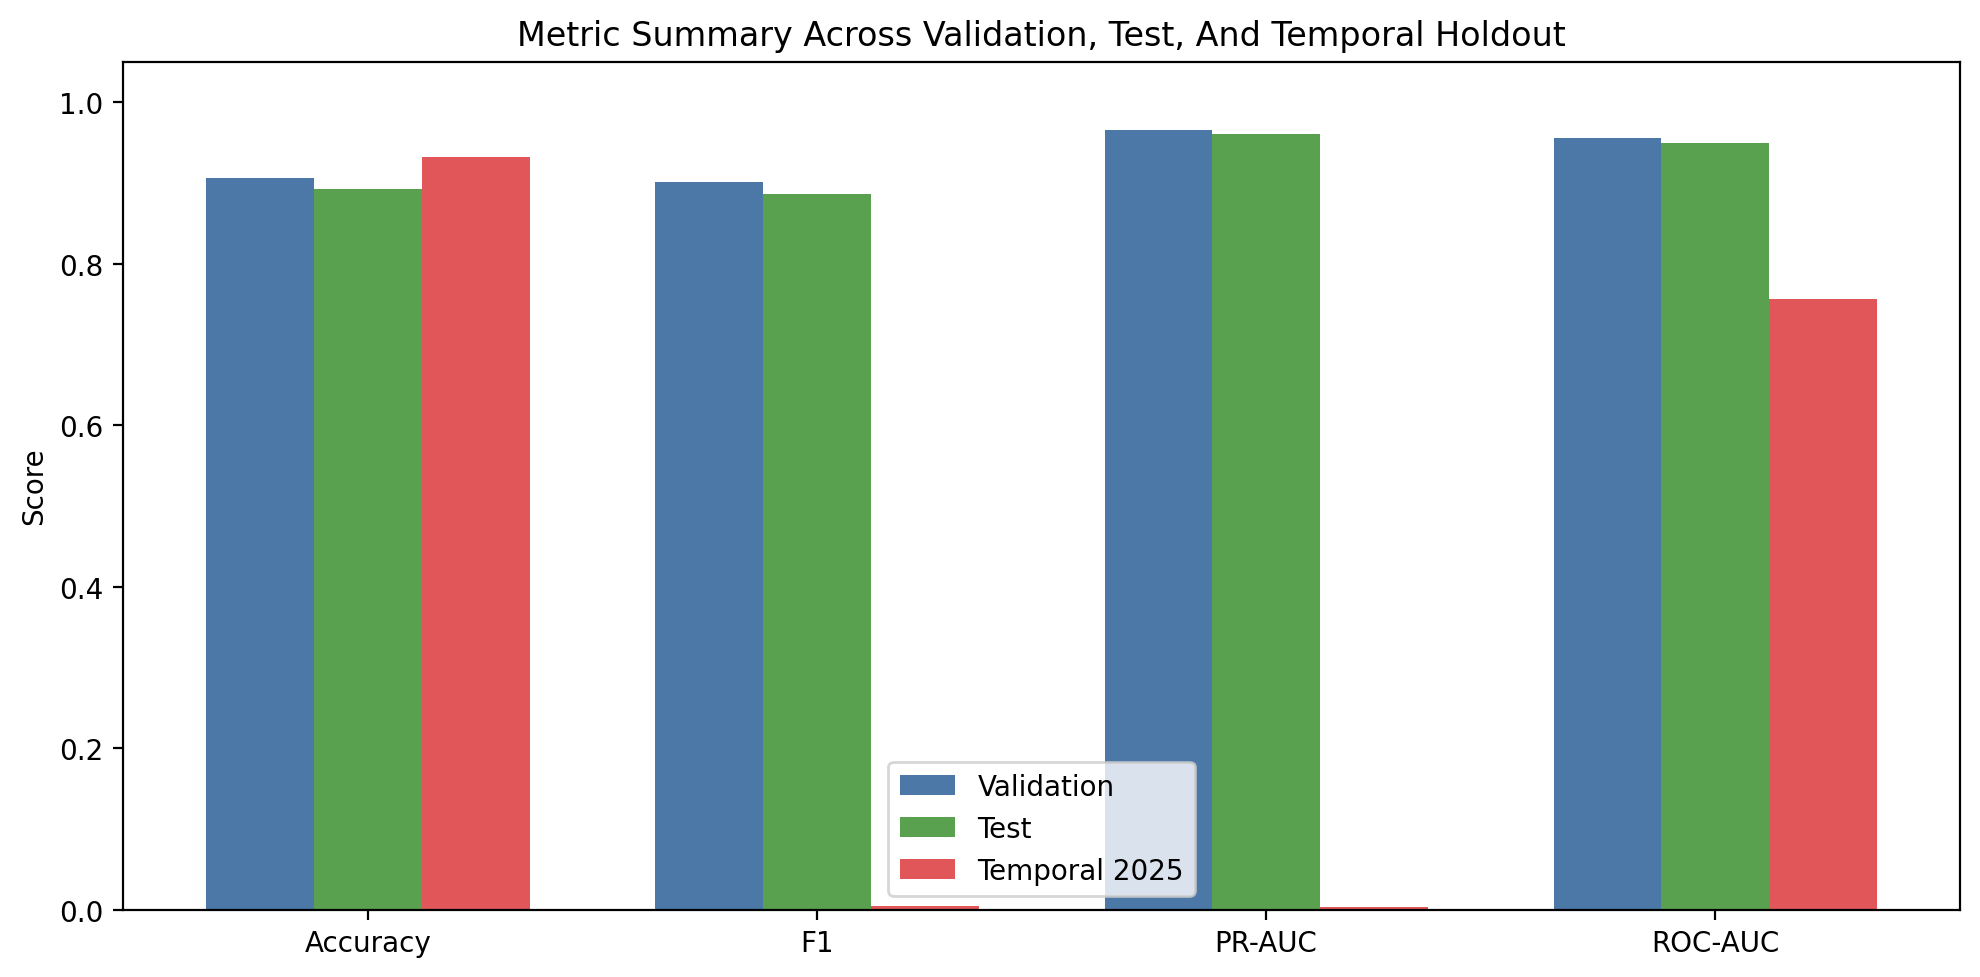

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'metric_summary.png')))

## Precision-Recall Curves

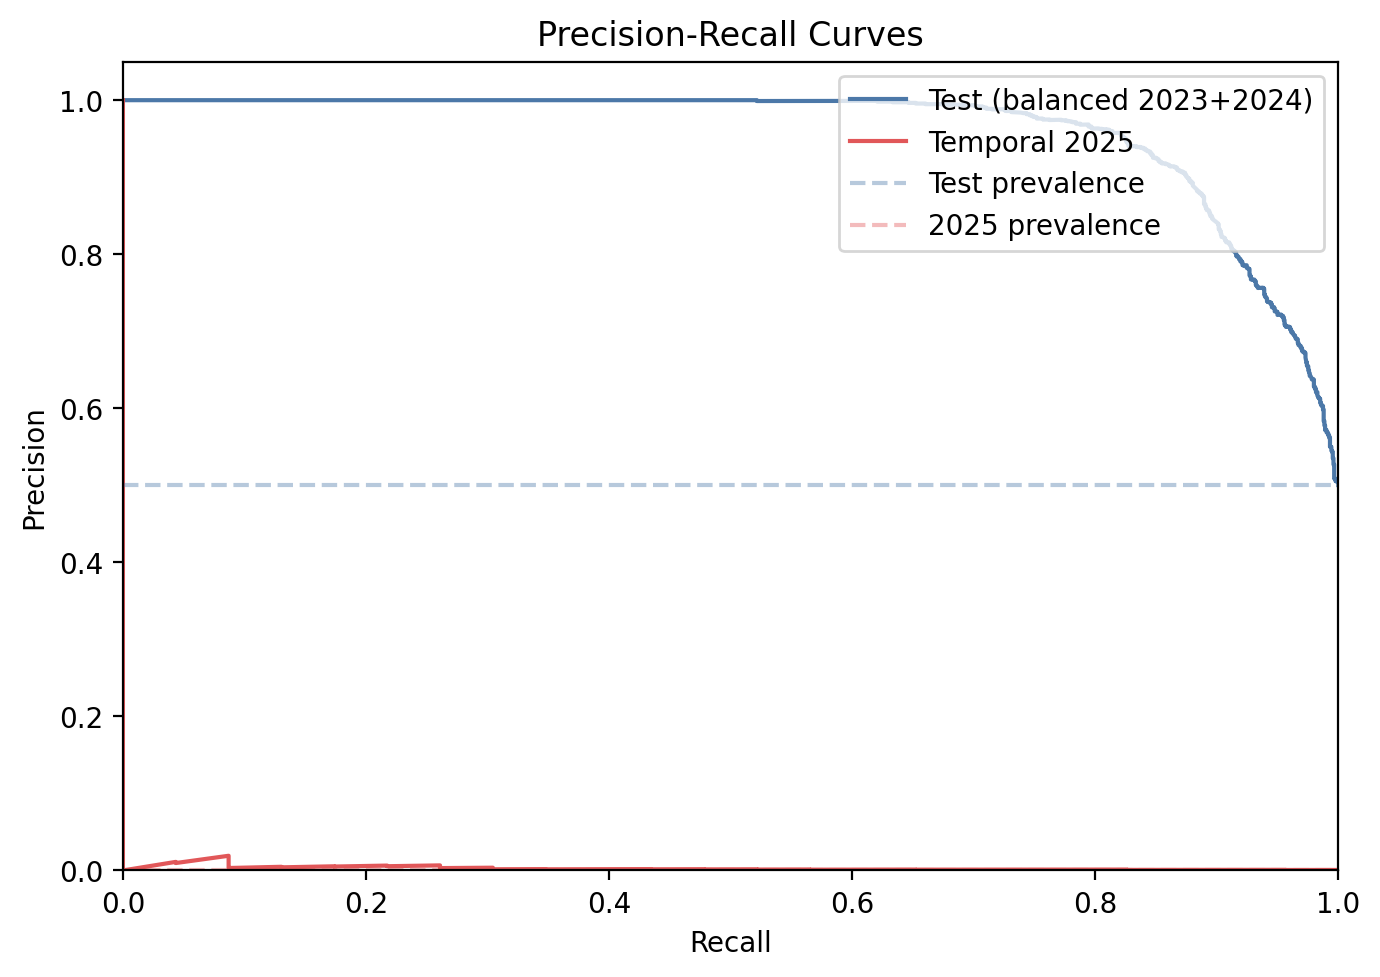

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'precision_recall_curves.png')))

## ROC Curves

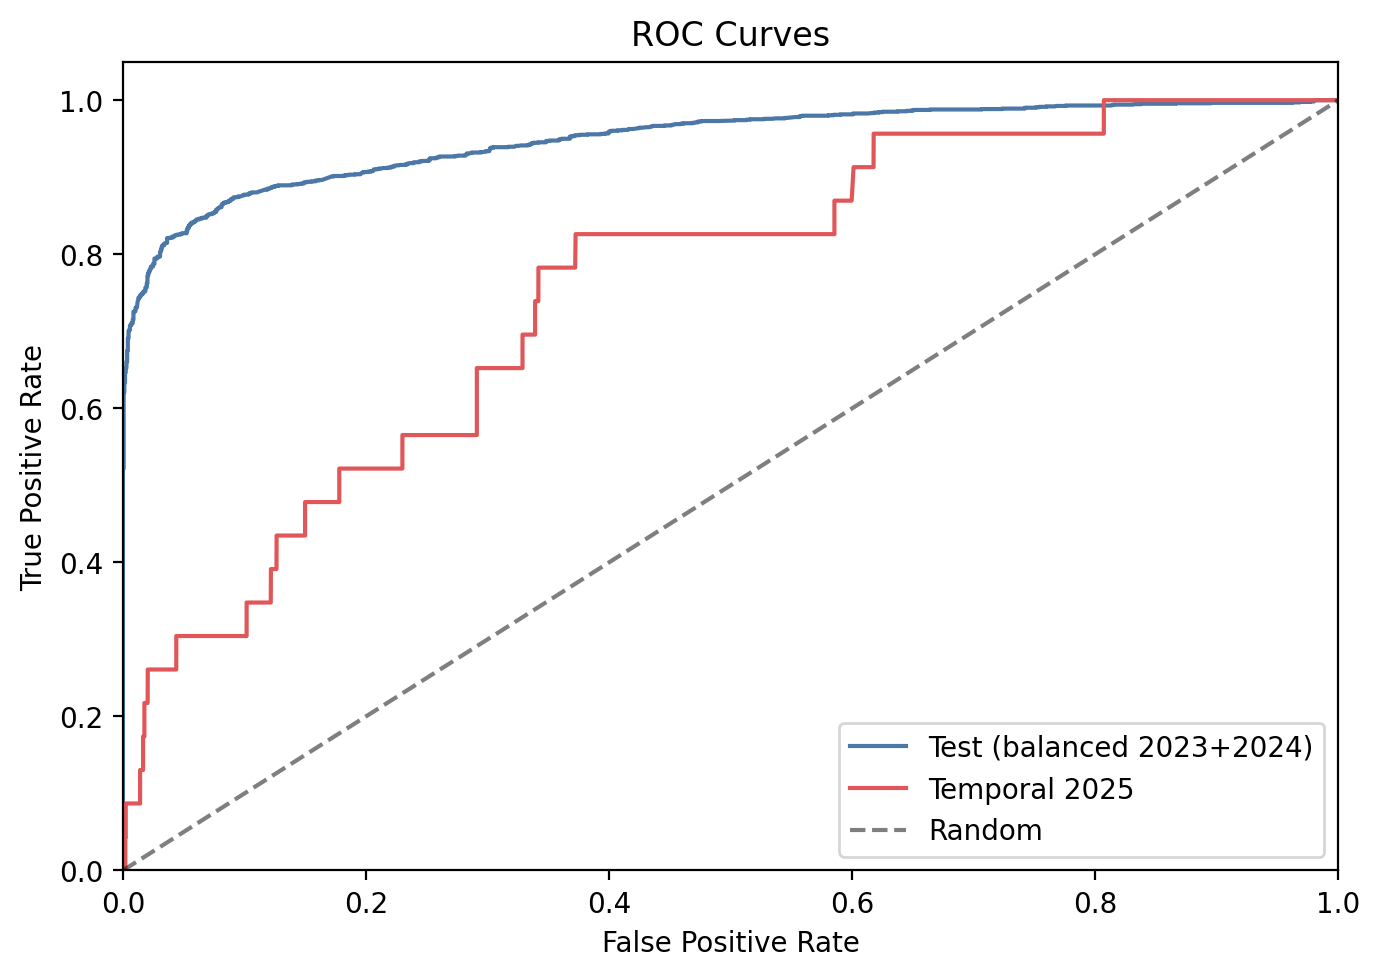

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'roc_curves.png')))

## Test Confusion Matrix

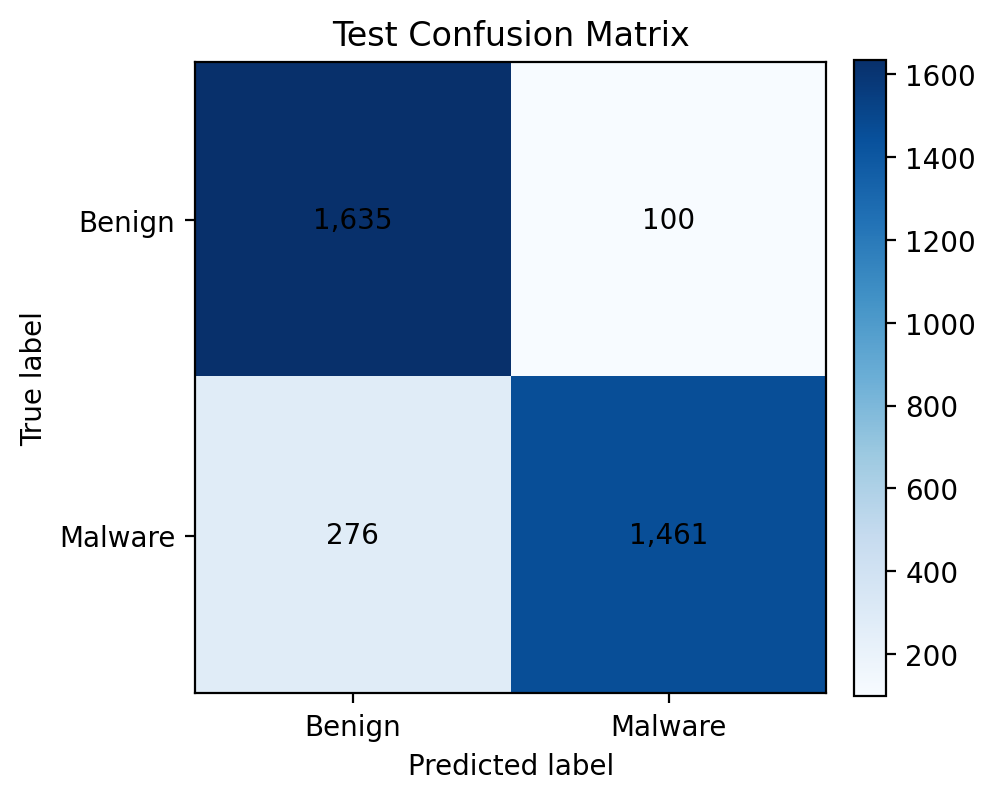

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'test_confusion_matrix.png')))

## Temporal 2025 Confusion Matrix

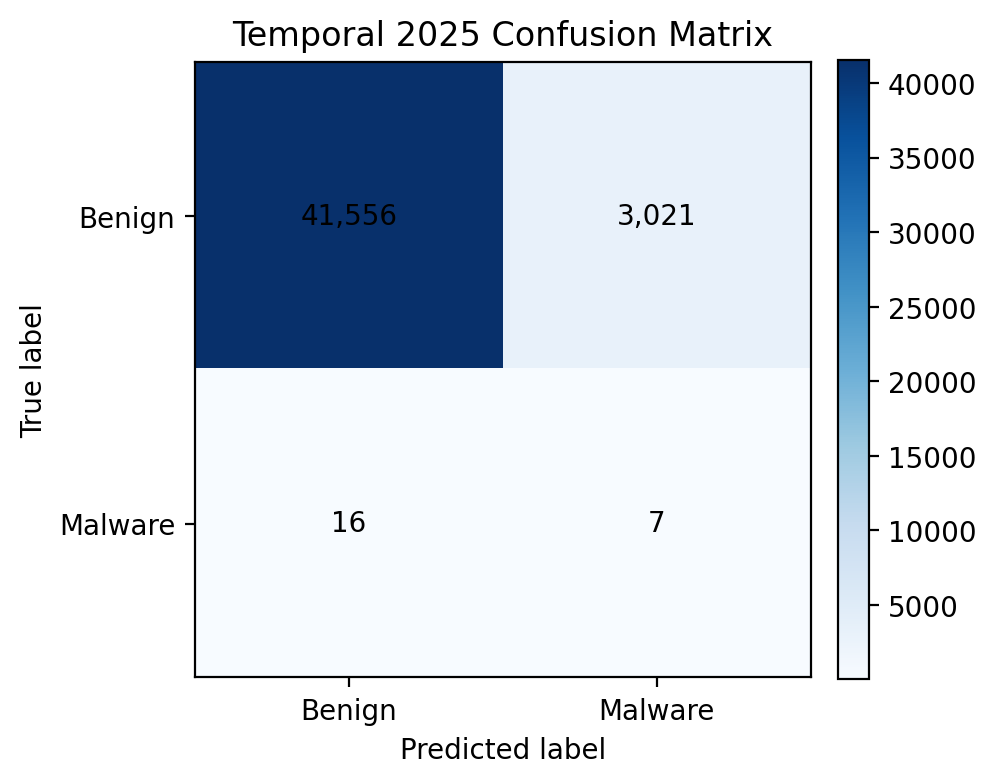

In [ ]:
display(Image(filename=str(FIGURES_DIR / 'temporal_2025_confusion_matrix.png')))

## Interpretation

- The balanced `2023+2024` slice is a strong recent training set for this Drebin-shaped feature space.
- The final test split remains strong on F1, PR-AUC, and ROC-AUC.
- The `2025` holdout remains difficult because it contains only `23` malware samples after rebuild, so precision collapses despite decent ranking behavior.
- The Android-facing export contract remains intact: TorchScript model, ordered `vocab.txt`, and custom-tokenizer parity.